In [16]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\aksha\Downloads\archive
['.ipynb_checkpoints', 'data', 'Ecommerce Order Dataset', 'Untitled.ipynb', 'Untitled1.ipynb', 'Untitled2.ipynb', 'Untitled3.ipynb', 'week3_outputs', 'week4_outputs']


In [65]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

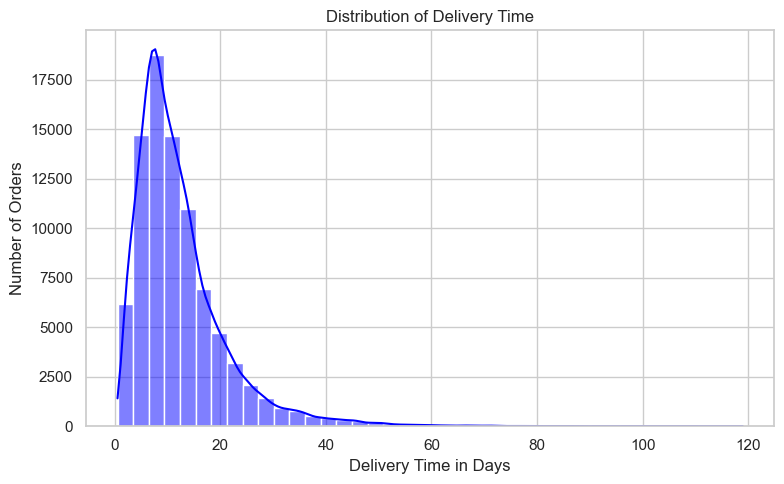

In [68]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=model_df,
    x="delivery_time_days",
    bins=40,
    kde=True,
    color="blue"
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time in Days")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

In [69]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [70]:
ROOT = Path.cwd()

print("Current notebook location:")
print(ROOT)

Current notebook location:
C:\Users\aksha\Downloads\archive


In [71]:
orders_files = list(ROOT.rglob("df_Orders.csv"))

if not orders_files:
    raise FileNotFoundError(
        "df_Orders.csv was not found.\n"
        "Extract archive(2).zip and place the extracted folder "
        "inside or beside your notebook folder."
    )

DATA = orders_files[0].parent

print("Dataset folder found:")
print(DATA)

Dataset folder found:
C:\Users\aksha\Downloads\archive\Ecommerce Order Dataset\test


In [72]:
csv_files = list(DATA.glob("*.csv"))

for file in csv_files:
    print(file.name)

df_Customers.csv
df_OrderItems.csv
df_Orders.csv
df_Payments.csv
df_Products.csv


In [73]:
orders = pd.read_csv(DATA / "df_Orders.csv")
items = pd.read_csv(DATA / "df_OrderItems.csv")
customers = pd.read_csv(DATA / "df_Customers.csv")
products = pd.read_csv(DATA / "df_Products.csv")
payments = pd.read_csv(DATA / "df_Payments.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [74]:
print("Orders:", orders.shape)
print("Order items:", items.shape)
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Payments:", payments.shape)

Orders: (38279, 4)
Order items: (38279, 5)
Customers: (38279, 4)
Products: (38279, 6)
Payments: (38279, 5)


In [75]:
display(orders.head())
display(items.head())
display(customers.head())
display(products.head())
display(payments.head())

,order_id,customer_id,order_purchase_timestamp,order_approved_at
0,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08
1,ohY8f4FEbX19,47TuLHF2s7X5,2018-06-02 17:13:12,2018-06-02 20:12:23
2,I28liQek73i2,dQ0dqI8Qwlj8,2018-01-08 11:01:30,2018-01-09 07:24:03
3,bBG1T89mlY8W,iQCmWhNkIczb,2017-03-10 10:24:46,2017-03-10 10:24:46
4,CYxJJSQS8Lbo,Dp2g6JH8tO5Z,2017-12-02 10:04:07,2017-12-05 04:13:30


,order_id,product_id,seller_id,price,shipping_charges
0,u6rPMRAYIGig,1slxdgbgWFax,3jwvL6ihC45G,24.10,20.90
1,ohY8f4FEbX19,77PgsiElQLeB,GlLj704QXlDB,42.89,12.28
2,I28liQek73i2,QVlD26X1y7NI,V3iKL8r9W9NR,50.21,67.11
3,bBG1T89mlY8W,yWlFGkKYfrpa,RNBdBKsXebna,89.10,62.05
4,CYxJJSQS8Lbo,h6MCbrwh5kiC,5Ja2lH0N2OZt,2139.99,9.41


,customer_id,customer_zip_code_prefix,customer_city,customer_state
0,I74lXDOfoqsp,6020,goiania,GO
1,47TuLHF2s7X5,23020,viamao,RS
2,dQ0dqI8Qwlj8,75094,campinas,SP
3,iQCmWhNkIczb,89284,santana de parnaiba,SP
4,Dp2g6JH8tO5Z,39810,aripuana,MT


,product_id,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1slxdgbgWFax,toys,50.0,16.0,5.0,11.0
1,77PgsiElQLeB,electronics,200.0,21.0,7.0,14.0
2,QVlD26X1y7NI,furniture_decor,1000.0,100.0,5.0,20.0
3,yWlFGkKYfrpa,toys,8950.0,40.0,30.0,40.0
4,h6MCbrwh5kiC,toys,2301.0,32.0,35.0,34.0


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,u6rPMRAYIGig,1,credit_card,2,155.77
1,ohY8f4FEbX19,1,credit_card,1,4.07
2,I28liQek73i2,1,wallet,1,381.59
3,bBG1T89mlY8W,1,credit_card,3,14.76
4,CYxJJSQS8Lbo,1,wallet,1,284.09


In [76]:
print("Orders columns:")
print(orders.columns.tolist())

print("\nOrder-items columns:")
print(items.columns.tolist())

print("\nCustomer columns:")
print(customers.columns.tolist())

print("\nProduct columns:")
print(products.columns.tolist())

print("\nPayment columns:")
print(payments.columns.tolist())

Orders columns:
['order_id', 'customer_id', 'order_purchase_timestamp', 'order_approved_at']

Order-items columns:
['order_id', 'product_id', 'seller_id', 'price', 'shipping_charges']

Customer columns:
['customer_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Product columns:
['product_id', 'product_category_name', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

Payment columns:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']


In [77]:
datasets = {
    "Orders": orders,
    "Order Items": items,
    "Customers": customers,
    "Products": products,
    "Payments": payments
}

for name, dataframe in datasets.items():
    print(f"\n{name}")
    print(dataframe.isnull().sum().sort_values(ascending=False).head(10))


Orders
order_approved_at           7
order_id                    0
customer_id                 0
order_purchase_timestamp    0
dtype: int64

Order Items
order_id            0
product_id          0
seller_id           0
price               0
shipping_charges    0
dtype: int64

Customers
customer_id                 0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Products
product_category_name    168
product_weight_g          10
product_length_cm         10
product_height_cm         10
product_width_cm          10
product_id                 0
dtype: int64

Payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


In [78]:
from pathlib import Path
import pandas as pd

ROOT = Path.cwd()

# Find df_Orders.csv specifically inside the train folder
orders_files = [
    file for file in ROOT.rglob("df_Orders.csv")
    if "train" in [folder.lower() for folder in file.parts]
]

if not orders_files:
    raise FileNotFoundError(
        "Training dataset was not found. Extract archive(2).zip "
        "and place the extracted folder beside the notebook."
    )

DATA = orders_files[0].parent

print("Training folder selected:")
print(DATA)

Training folder selected:
C:\Users\aksha\Downloads\archive\Ecommerce Order Dataset\train


In [79]:
orders = pd.read_csv(DATA / "df_Orders.csv")
items = pd.read_csv(DATA / "df_OrderItems.csv")
customers = pd.read_csv(DATA / "df_Customers.csv")
products = pd.read_csv(DATA / "df_Products.csv")
payments = pd.read_csv(DATA / "df_Payments.csv")

print("Training files loaded successfully!")
print("Orders shape:", orders.shape)
print(orders.columns.tolist())

Training files loaded successfully!
Orders shape: (89316, 7)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_timestamp', 'order_estimated_delivery_date']


In [80]:
date_columns = [
    "order_purchase_timestamp",
    "order_delivered_timestamp",
    "order_estimated_delivery_date"
]

for column in date_columns:
    orders[column] = pd.to_datetime(
        orders[column],
        errors="coerce"
    )

print(orders[date_columns].dtypes)
display(orders[date_columns].head())

order_purchase_timestamp         datetime64[us]
order_delivered_timestamp        datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


,order_purchase_timestamp,order_delivered_timestamp,order_estimated_delivery_date
0,2017-10-22 18:57:54,2017-10-26 22:19:52,2017-11-09
1,2018-06-20 21:40:31,2018-07-03 22:51:22,2018-07-24
2,2018-02-16 16:19:31,2018-02-27 01:29:50,2018-03-08
3,2018-08-18 18:04:29,2018-08-27 20:03:51,2018-09-19
4,2017-12-22 16:44:04,2018-01-05 19:22:49,2018-01-18


In [81]:
delivery_orders = orders[
    (orders["order_status"] == "delivered") &
    (orders["order_purchase_timestamp"].notna()) &
    (orders["order_delivered_timestamp"].notna())
].copy()

print("Delivered orders:", delivery_orders.shape)

Delivered orders: (87422, 7)


In [82]:
delivery_orders["delivery_time_days"] = (
    delivery_orders["order_delivered_timestamp"] -
    delivery_orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400

display(
    delivery_orders[
        [
            "order_purchase_timestamp",
            "order_delivered_timestamp",
            "delivery_time_days"
        ]
    ].head()
)

,order_purchase_timestamp,order_delivered_timestamp,delivery_time_days
0,2017-10-22 18:57:54,2017-10-26 22:19:52,4.140255
1,2018-06-20 21:40:31,2018-07-03 22:51:22,13.049201
2,2018-02-16 16:19:31,2018-02-27 01:29:50,10.382164
3,2018-08-18 18:04:29,2018-08-27 20:03:51,9.082894
4,2017-12-22 16:44:04,2018-01-05 19:22:49,14.110243


In [83]:
delivery_orders = delivery_orders[
    delivery_orders["delivery_time_days"].between(0, 120)
].copy()

print(delivery_orders["delivery_time_days"].describe())

count    87392.000000
mean        12.383892
std          8.852077
min          0.533414
25%          6.730784
50%         10.191690
75%         15.445405
max        118.969560
Name: delivery_time_days, dtype: float64


In [84]:
products = products.drop_duplicates(
    subset="product_id"
).copy()

print("Unique products:", products.shape)

Unique products: (27451, 6)


In [85]:
item_product_data = items.merge(
    products,
    on="product_id",
    how="left",
    validate="many_to_one"
)

print(item_product_data.shape)
display(item_product_data.head())

(89316, 10)


,order_id,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,Axfy13Hk4PIk,90K0C1fIyQUf,ZWM05J9LcBSF,223.51,84.65,toys,491.0,19.0,12.0,16.0
1,v6px92oS8cLG,qejhpMGGVcsl,IjlpYfhUbRQs,170.80,23.79,watches_gifts,440.0,18.0,14.0,17.0
2,Ulpf9skrhjfm,qUS5d2pEAyxJ,77p2EYxcM9MD,64.40,17.38,costruction_tools_garden,2200.0,16.0,16.0,16.0
3,bwJVWupf2keN,639iGvMyv0De,jWzS0ayv9TGf,264.50,30.72,toys,1450.0,68.0,3.0,48.0
4,Dd0QnrMk9Cj5,1lycYGcsic2F,l1pYW6GBnPMr,779.90,30.66,toys,300.0,17.0,4.0,12.0


In [86]:
payment_features = payments.groupby(
    "order_id",
    as_index=False
).agg(
    payment_value=("payment_value", "sum"),
    payment_installments=("payment_installments", "max"),
    payment_type=("payment_type", "first")
)

display(payment_features.head())

,order_id,payment_value,payment_installments,payment_type
0,001gkk6BwKEB,265.90,2,credit_card
1,0029bAIZFMKA,217.82,1,wallet
2,002Jk8hp9Bhy,1272.76,1,wallet
3,002ohHsWSKrP,650.65,4,credit_card
4,0041NijdAYB0,70.34,3,credit_card


In [87]:
model_df = delivery_orders.merge(
    item_features,
    on="order_id",
    how="left",
    validate="one_to_one"
)

model_df = model_df.merge(
    customers,
    on="customer_id",
    how="left",
    validate="one_to_one"
)

model_df = model_df.merge(
    payment_features,
    on="order_id",
    how="left",
    validate="one_to_one"
)

print("Final dataset shape:", model_df.shape)
display(model_df.head())

Final dataset shape: (87392, 21)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,delivery_time_days,price,shipping_charges,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category,customer_zip_code_prefix,customer_city,customer_state,payment_value,payment_installments,payment_type
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,4.140255,223.51,84.65,491.0,19.0,12.0,16.0,toys,58125,varzea paulista,SP,259.14,1,credit_card
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,13.049201,170.80,23.79,440.0,18.0,14.0,17.0,watches_gifts,3112,armacao dos buzios,RJ,382.39,8,credit_card
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,10.382164,64.40,17.38,2200.0,16.0,16.0,16.0,costruction_tools_garden,4119,jandira,SP,249.25,4,credit_card
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,9.082894,264.50,30.72,1450.0,68.0,3.0,48.0,toys,18212,uberlandia,MG,27.79,2,credit_card
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,14.110243,779.90,30.66,300.0,17.0,4.0,12.0,toys,88868,ilhabela,SP,76.15,1,credit_card


In [88]:
model_df["purchase_month"] = (
    model_df["order_purchase_timestamp"].dt.month.astype(str)
)

model_df["purchase_weekday"] = (
    model_df["order_purchase_timestamp"].dt.dayofweek.astype(str)
)

model_df = model_df.sort_values(
    "order_purchase_timestamp"
).reset_index(drop=True)

print("Date features created successfully!")

Date features created successfully!


In [89]:
features = [
    "price",
    "shipping_charges",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
    "payment_value",
    "payment_installments",
    "customer_state",
    "product_category",
    "payment_type",
    "purchase_month",
    "purchase_weekday"
]

target = "delivery_time_days"

X = model_df[features].copy()
y = model_df[target].copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (87392, 13)
Target shape: (87392,)


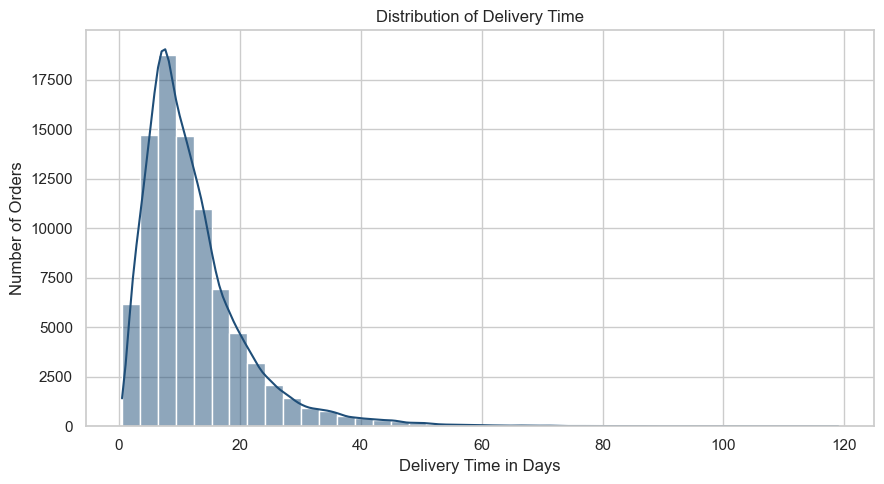

In [90]:
plt.figure(figsize=(9, 5))

sns.histplot(
    y,
    bins=40,
    kde=True,
    color="#1F4E78"
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time in Days")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

In [91]:
split_index = int(len(model_df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training records:", len(X_train))
print("Testing records:", len(X_test))
print(
    "Testing period starts:",
    model_df.iloc[split_index]["order_purchase_timestamp"]
)

Training records: 69913
Testing records: 17479
Testing period starts: 2018-05-21 23:36:23


In [92]:
numeric_features = [
    "price",
    "shipping_charges",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
    "payment_value",
    "payment_installments"
]

categorical_features = [
    "customer_state",
    "product_category",
    "payment_type",
    "purchase_month",
    "purchase_weekday"
]

In [93]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created!")

Preprocessing pipeline created!


In [94]:
def evaluate_model(model_name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [95]:
baseline_value = y_train.median()

baseline_predictions = np.full(
    len(y_test),
    baseline_value
)

results = []

results.append(
    evaluate_model(
        "Median Baseline",
        y_test,
        baseline_predictions
    )
)

print("Baseline delivery time:", baseline_value)

Baseline delivery time: 11.090856481481481


In [96]:
ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=10.0))
    ]
)

ridge_pipeline.fit(X_train, y_train)

ridge_predictions = ridge_pipeline.predict(X_test)

results.append(
    evaluate_model(
        "Ridge Regression",
        y_test,
        ridge_predictions
    )
)

print("Ridge Regression trained successfully!")

Ridge Regression trained successfully!


In [97]:
tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeRegressor(
                max_depth=10,
                min_samples_leaf=20,
                random_state=42
            )
        )
    ]
)

tree_pipeline.fit(X_train, y_train)

tree_predictions = tree_pipeline.predict(X_test)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        tree_predictions
    )
)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [98]:
forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                max_depth=18,
                min_samples_leaf=5,
                max_features=0.8,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

forest_pipeline.fit(X_train, y_train)

forest_predictions = forest_pipeline.predict(X_test)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        forest_predictions
    )
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [99]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="MAE"
).reset_index(drop=True)

display(
    results_df.style.format(
        {
            "MAE": "{:.2f}",
            "RMSE": "{:.2f}",
            "R2": "{:.3f}"
        }
    )
)

,Model,MAE,RMSE,R2
0,Ridge Regression,4.16,5.53,0.069
1,Random Forest,4.41,5.64,0.033
2,Decision Tree,4.63,5.93,-0.068
3,Median Baseline,4.87,6.18,-0.161


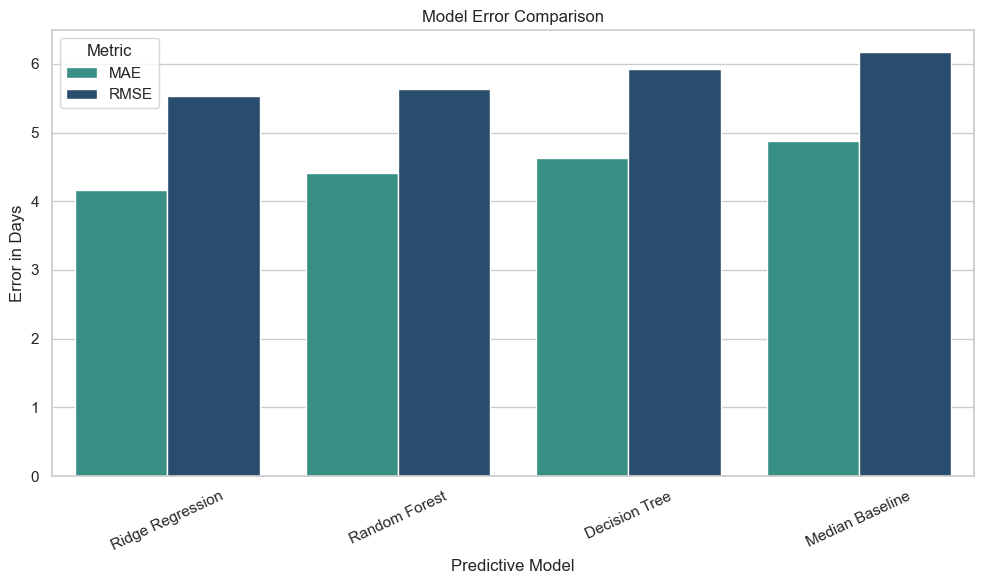

In [100]:
comparison_data = results_df.melt(
    id_vars="Model",
    value_vars=["MAE", "RMSE"],
    var_name="Metric",
    value_name="Error"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparison_data,
    x="Model",
    y="Error",
    hue="Metric",
    palette=["#2A9D8F", "#1F4E78"]
)

plt.title("Model Error Comparison")
plt.xlabel("Predictive Model")
plt.ylabel("Error in Days")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [101]:
tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeRegressor(random_state=42)
        )
    ]
)

parameter_grid = {
    "model__max_depth": [6, 10, 14],
    "model__min_samples_leaf": [10, 30, 75]
}

time_cv = TimeSeriesSplit(n_splits=3)

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=parameter_grid,
    scoring="neg_mean_absolute_error",
    cv=time_cv,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print(
    "Best cross-validation MAE:",
    round(-grid_search.best_score_, 2)
)

Best parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 75}
Best cross-validation MAE: 6.17


In [102]:
tuned_tree = grid_search.best_estimator_

tuned_predictions = tuned_tree.predict(X_test)

tuned_result = evaluate_model(
    "Tuned Decision Tree",
    y_test,
    tuned_predictions
)

results_df = pd.concat(
    [
        results_df,
        pd.DataFrame([tuned_result])
    ],
    ignore_index=True
)

results_df = (
    results_df
    .drop_duplicates(subset="Model", keep="last")
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(
    results_df.style.format(
        {
            "MAE": "{:.2f}",
            "RMSE": "{:.2f}",
            "R2": "{:.3f}"
        }
    )
)

,Model,MAE,RMSE,R2
0,Ridge Regression,4.16,5.53,0.069
1,Random Forest,4.41,5.64,0.033
2,Tuned Decision Tree,4.62,5.90,-0.059
3,Decision Tree,4.63,5.93,-0.068
4,Median Baseline,4.87,6.18,-0.161


In [103]:
best_model = ridge_pipeline
best_predictions = ridge_predictions

best_mae = mean_absolute_error(
    y_test,
    best_predictions
)

best_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        best_predictions
    )
)

best_r2 = r2_score(
    y_test,
    best_predictions
)

print("Selected model: Ridge Regression")
print("MAE:", round(best_mae, 2), "days")
print("RMSE:", round(best_rmse, 2), "days")
print("R-squared:", round(best_r2, 3))

Selected model: Ridge Regression
MAE: 4.16 days
RMSE: 5.53 days
R-squared: 0.069


In [104]:
baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

improvement = (
    (baseline_mae - best_mae) /
    baseline_mae
) * 100

print("Baseline MAE:", round(baseline_mae, 2))
print("Model MAE:", round(best_mae, 2))
print("Improvement:", round(improvement, 2), "%")

Baseline MAE: 4.87
Model MAE: 4.16
Improvement: 14.57 %


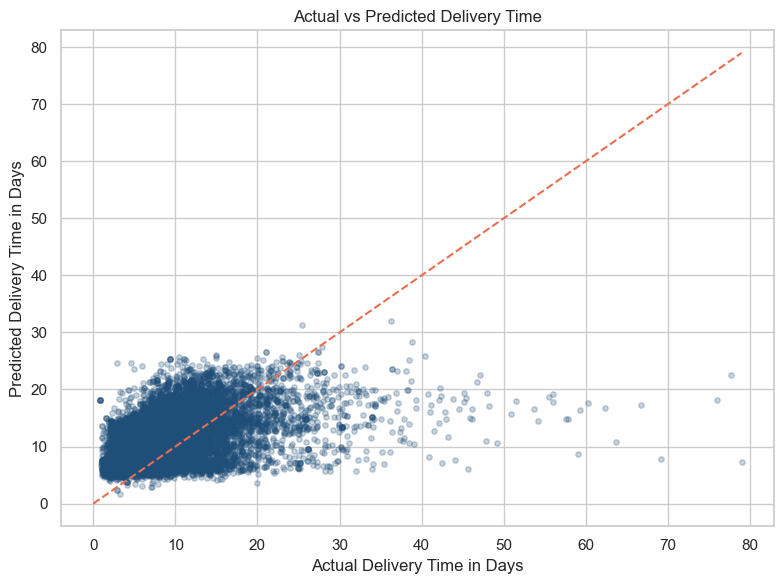

In [105]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.25,
    s=15,
    color="#1F4E78"
)

plot_limit = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [0, plot_limit],
    [0, plot_limit],
    linestyle="--",
    color="#E76F51"
)

plt.title("Actual vs Predicted Delivery Time")
plt.xlabel("Actual Delivery Time in Days")
plt.ylabel("Predicted Delivery Time in Days")
plt.tight_layout()
plt.show()

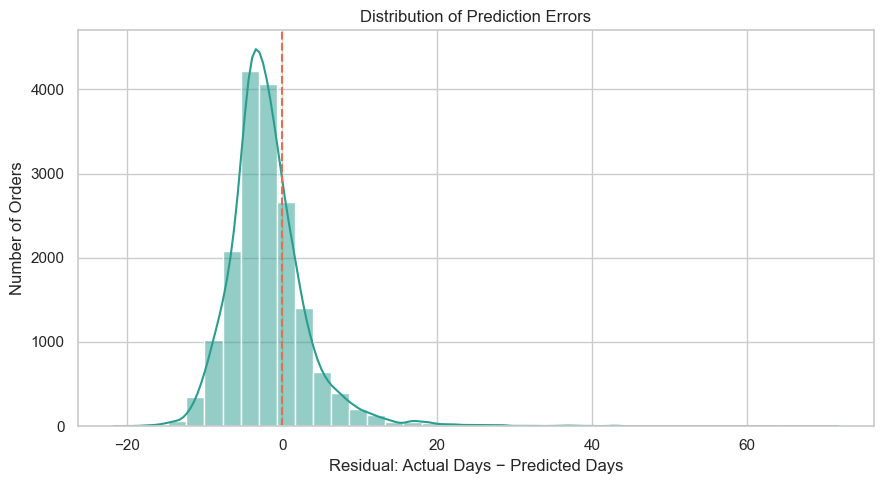

In [106]:
residuals = y_test.to_numpy() - best_predictions

plt.figure(figsize=(9, 5))

sns.histplot(
    residuals,
    bins=40,
    kde=True,
    color="#2A9D8F"
)

plt.axvline(
    0,
    linestyle="--",
    color="#E76F51"
)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Residual: Actual Days − Predicted Days")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

In [107]:
sample_size = min(4000, len(X_test))

sample_indices = np.linspace(
    0,
    len(X_test) - 1,
    sample_size
).astype(int)

importance_result = permutation_importance(
    best_model,
    X_test.iloc[sample_indices],
    y_test.iloc[sample_indices],
    scoring="neg_mean_absolute_error",
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame(
    {
        "Feature": features,
        "Importance": importance_result.importances_mean
    }
).sort_values(
    "Importance",
    ascending=False
)

display(importance_df)

,Feature,Importance
8,customer_state,1.281422
9,product_category,0.041769
11,purchase_month,0.030706
10,payment_type,0.029670
12,purchase_weekday,0.026227
3,product_length_cm,0.016132
2,product_weight_g,0.006381
4,product_height_cm,0.003743
7,payment_installments,0.001917
1,shipping_charges,0.000921


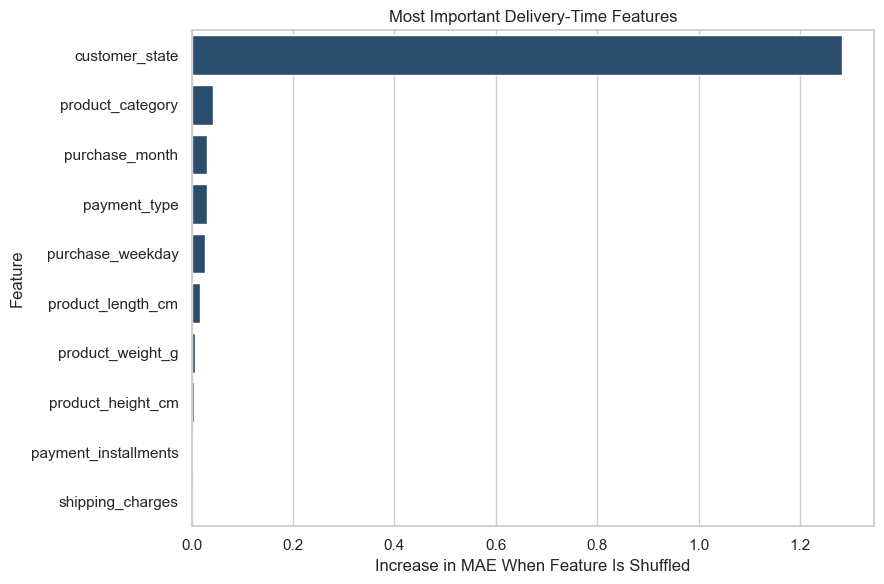

In [108]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature",
    color="#1F4E78"
)

plt.title("Most Important Delivery-Time Features")
plt.xlabel("Increase in MAE When Feature Is Shuffled")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [109]:
prediction_results = model_df.iloc[
    split_index:
][
    [
        "order_id",
        "order_purchase_timestamp",
        "customer_state"
    ]
].copy()

prediction_results["actual_delivery_days"] = (
    y_test.to_numpy()
)

prediction_results["predicted_delivery_days"] = (
    best_predictions
)

prediction_results["absolute_error_days"] = np.abs(
    prediction_results["actual_delivery_days"] -
    prediction_results["predicted_delivery_days"]
)

prediction_results["risk_segment"] = pd.qcut(
    prediction_results["predicted_delivery_days"],
    q=4,
    labels=[
        "Low",
        "Moderate",
        "High",
        "Critical"
    ]
)

display(prediction_results.head())

,order_id,order_purchase_timestamp,customer_state,actual_delivery_days,predicted_delivery_days,absolute_error_days,risk_segment
69913,xviyzTqJujME,2018-05-21 23:36:23,RJ,16.844653,14.708988,2.135665,Critical
69914,d9cVQCKliNTM,2018-05-22 00:49:37,SP,13.878368,9.692781,4.185588,High
69915,gUlzgUXBYc0u,2018-05-22 01:07:35,SP,1.753206,6.697734,4.944528,Low
69916,AT7y0maHyNqY,2018-05-22 01:07:35,SP,1.753206,6.697734,4.944528,Low
69917,HCwliiA5LB5G,2018-05-22 01:43:18,MG,12.548646,11.516077,1.032569,High


In [110]:
risk_summary = prediction_results.groupby(
    "risk_segment",
    observed=True
).agg(
    total_orders=("order_id", "count"),
    average_predicted_days=(
        "predicted_delivery_days",
        "mean"
    ),
    average_actual_days=(
        "actual_delivery_days",
        "mean"
    ),
    average_error_days=(
        "absolute_error_days",
        "mean"
    )
).reset_index()

display(
    risk_summary.style.format(
        {
            "average_predicted_days": "{:.2f}",
            "average_actual_days": "{:.2f}",
            "average_error_days": "{:.2f}"
        }
    )
)

,risk_segment,total_orders,average_predicted_days,average_actual_days,average_error_days
0,Low,4370,6.22,5.91,2.88
1,Moderate,4370,8.10,7.29,3.25
2,High,4369,11.81,9.26,4.41
3,Critical,4370,16.60,12.72,6.12


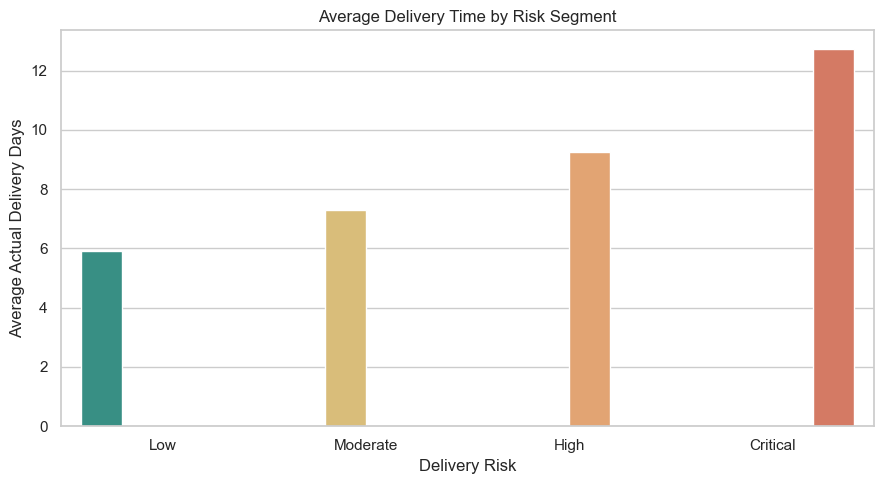

In [111]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=risk_summary,
    x="risk_segment",
    y="average_actual_days",
    hue="risk_segment",
    palette=[
        "#2A9D8F",
        "#E9C46A",
        "#F4A261",
        "#E76F51"
    ],
    legend=False
)

plt.title("Average Delivery Time by Risk Segment")
plt.xlabel("Delivery Risk")
plt.ylabel("Average Actual Delivery Days")
plt.tight_layout()
plt.show()

In [112]:
OUTPUT = Path("week4_outputs")
OUTPUT.mkdir(exist_ok=True)

joblib.dump(
    best_model,
    OUTPUT / "best_delivery_time_model.joblib"
)

results_df.to_csv(
    OUTPUT / "model_comparison.csv",
    index=False
)

importance_df.to_csv(
    OUTPUT / "feature_importance.csv",
    index=False
)

prediction_results.to_csv(
    OUTPUT / "test_predictions.csv",
    index=False
)

risk_summary.to_csv(
    OUTPUT / "risk_segment_summary.csv",
    index=False
)

print("All outputs saved successfully!")
print("Output folder:", OUTPUT.resolve())

All outputs saved successfully!
Output folder: C:\Users\aksha\Downloads\archive\week4_outputs
